# Assignment 4: Python Statistics Walkthrough

This notebook follows the statistics tutorial from the SciPy Lecture Notes.
The purpose is to practice loading data, summarizing variables, performing
statistical tests, fitting regression models, and creating statistical plots.

In [1]:
%pip install statsmodels seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import seaborn

# Data Representation and Interaction

This section loads the brain size dataset and examines its structure using pandas.

In [3]:
from pathlib import Path
from urllib.request import urlretrieve

# Create the examples folder
Path("../examples").mkdir(exist_ok=True)

# Download the dataset used in the SciPy tutorial
url = "https://scipy-lectures.org/_downloads/brain_size.csv"
file_path = "../examples/brain_size.csv"

urlretrieve(url, file_path)

print("Downloaded:", Path(file_path).exists())

Downloaded: True


In [4]:
data = pd.read_csv(
    "../examples/brain_size.csv",
    sep=";",
    na_values=".",
    index_col=0
)

data

,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
1,Female,133,132,124,118.0,64.5,816932
2,Male,140,150,124,NaN,72.5,1001121
3,Male,139,123,150,143.0,73.3,1038437
4,Male,133,129,128,172.0,68.8,965353
5,Female,137,132,134,147.0,65.0,951545
6,Female,99,90,110,146.0,69.0,928799
7,Female,138,136,131,138.0,64.5,991305
8,Female,92,90,98,175.0,66.0,854258
9,Male,89,93,84,134.0,66.3,904858
10,Male,133,114,147,172.0,68.8,955466


In [5]:
data.shape

(40, 7)

In [6]:
data.columns

Index(['Gender', 'FSIQ', 'VIQ', 'PIQ', 'Weight', 'Height', 'MRI_Count'], dtype='object')

In [7]:
print(data["Gender"])

1     Female
2       Male
3       Male
4       Male
5     Female
6     Female
7     Female
8     Female
9       Male
10      Male
11    Female
12      Male
13      Male
14    Female
15    Female
16    Female
17    Female
18      Male
19    Female
20      Male
21      Male
22      Male
23    Female
24      Male
25    Female
26      Male
27    Female
28      Male
29    Female
30    Female
31    Female
32      Male
33      Male
34      Male
35    Female
36    Female
37      Male
38    Female
39      Male
40      Male
Name: Gender, dtype: object


In [8]:
data[data["Gender"] == "Female"]["VIQ"].mean()

np.float64(109.45)

In [9]:
data.describe()

,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
count,40.000000,40.000000,40.00000,38.000000,39.000000,4.000000e+01
mean,113.450000,112.350000,111.02500,151.052632,68.525641,9.087550e+05
std,24.082071,23.616107,22.47105,23.478509,3.994649,7.228205e+04
min,77.000000,71.000000,72.00000,106.000000,62.000000,7.906190e+05
25%,89.750000,90.000000,88.25000,135.250000,66.000000,8.559185e+05
50%,116.500000,113.000000,115.00000,146.500000,68.000000,9.053990e+05
75%,135.500000,129.750000,128.00000,172.000000,70.500000,9.500780e+05
max,144.000000,150.000000,150.00000,192.000000,77.000000,1.079549e+06


In [10]:
groupby_gender = data.groupby("Gender")

In [11]:
for gender, values in groupby_gender["VIQ"]:
    print((gender, values.mean()))

('Female', np.float64(109.45))
('Male', np.float64(115.25))


In [12]:
groupby_gender.mean(numeric_only=True)

,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
Gender,,,,,,
Female,111.9,109.45,110.45,137.200000,65.765000,862654.6
Male,115.0,115.25,111.60,166.444444,71.431579,954855.4


In [13]:
data["VIQ"].mean()

np.float64(112.35)

# Question 2: Number of female and male participants

data["Gender"].value_counts()

In [14]:
data.assign(
    Log_MRI_Count=np.log(data["MRI_Count"])
).groupby("Gender")["Log_MRI_Count"].mean()

Gender
Female    13.665830
Male      13.767731
Name: Log_MRI_Count, dtype: float64

## Plotting the Data

This section uses scatter matrices to examine relationships among the numerical variables.

array([[<Axes: xlabel='Weight', ylabel='Weight'>,
        <Axes: xlabel='Height', ylabel='Weight'>,
        <Axes: xlabel='MRI_Count', ylabel='Weight'>],
       [<Axes: xlabel='Weight', ylabel='Height'>,
        <Axes: xlabel='Height', ylabel='Height'>,
        <Axes: xlabel='MRI_Count', ylabel='Height'>],
       [<Axes: xlabel='Weight', ylabel='MRI_Count'>,
        <Axes: xlabel='Height', ylabel='MRI_Count'>,
        <Axes: xlabel='MRI_Count', ylabel='MRI_Count'>]], dtype=object)

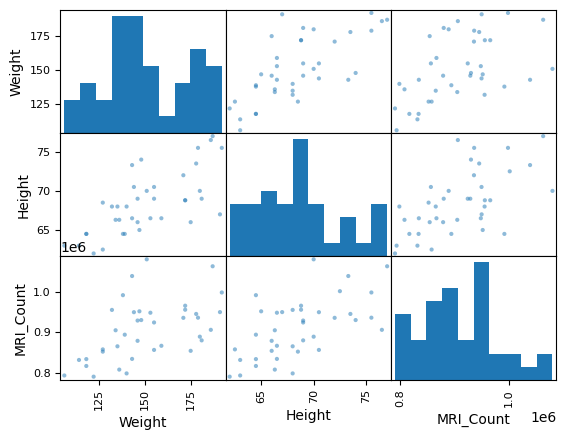

In [15]:
pd.plotting.scatter_matrix(
    data[["Weight", "Height", "MRI_Count"]]
)

The scatter matrix shows the distributions of weight, height, and MRI count, as well as the relationships between these variables. Some missing values are present in weight and height, but pandas automatically leaves them out of the relevant plots.

array([[<Axes: xlabel='PIQ', ylabel='PIQ'>,
        <Axes: xlabel='VIQ', ylabel='PIQ'>,
        <Axes: xlabel='FSIQ', ylabel='PIQ'>],
       [<Axes: xlabel='PIQ', ylabel='VIQ'>,
        <Axes: xlabel='VIQ', ylabel='VIQ'>,
        <Axes: xlabel='FSIQ', ylabel='VIQ'>],
       [<Axes: xlabel='PIQ', ylabel='FSIQ'>,
        <Axes: xlabel='VIQ', ylabel='FSIQ'>,
        <Axes: xlabel='FSIQ', ylabel='FSIQ'>]], dtype=object)

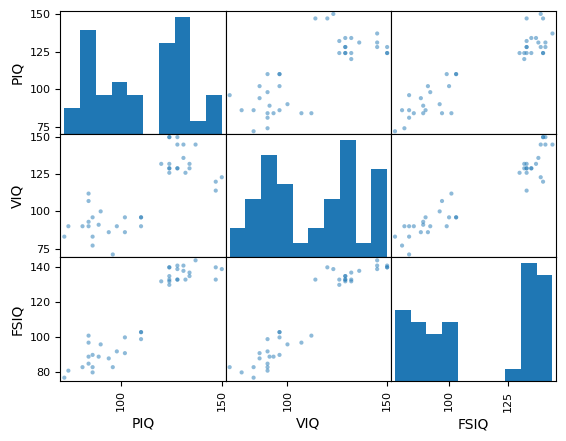

In [16]:
pd.plotting.scatter_matrix(
    data[["PIQ", "VIQ", "FSIQ"]]
)

The three IQ measurements show strong positive relationships. The distributions also appear to contain two possible subgroups, so the next plots examine whether these groups may correspond to gender.

array([[<Axes: xlabel='PIQ', ylabel='PIQ'>,
        <Axes: xlabel='VIQ', ylabel='PIQ'>,
        <Axes: xlabel='FSIQ', ylabel='PIQ'>],
       [<Axes: xlabel='PIQ', ylabel='VIQ'>,
        <Axes: xlabel='VIQ', ylabel='VIQ'>,
        <Axes: xlabel='FSIQ', ylabel='VIQ'>],
       [<Axes: xlabel='PIQ', ylabel='FSIQ'>,
        <Axes: xlabel='VIQ', ylabel='FSIQ'>,
        <Axes: xlabel='FSIQ', ylabel='FSIQ'>]], dtype=object)

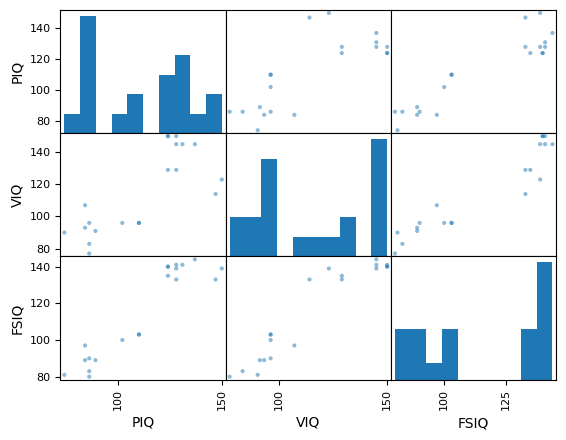

In [17]:
male_data = data[data["Gender"] == "Male"]

pd.plotting.scatter_matrix(
    male_data[["PIQ", "VIQ", "FSIQ"]]
)

array([[<Axes: xlabel='PIQ', ylabel='PIQ'>,
        <Axes: xlabel='VIQ', ylabel='PIQ'>,
        <Axes: xlabel='FSIQ', ylabel='PIQ'>],
       [<Axes: xlabel='PIQ', ylabel='VIQ'>,
        <Axes: xlabel='VIQ', ylabel='VIQ'>,
        <Axes: xlabel='FSIQ', ylabel='VIQ'>],
       [<Axes: xlabel='PIQ', ylabel='FSIQ'>,
        <Axes: xlabel='VIQ', ylabel='FSIQ'>,
        <Axes: xlabel='FSIQ', ylabel='FSIQ'>]], dtype=object)

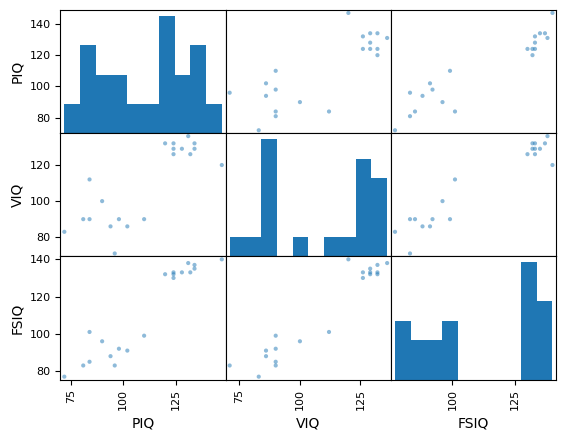

In [18]:
female_data = data[data["Gender"] == "Female"]

pd.plotting.scatter_matrix(
    female_data[["PIQ", "VIQ", "FSIQ"]]
)

### Exercise Interpretation

The two possible IQ subgroups do not appear to correspond clearly to gender. Both the male and female datasets contain participants with lower and higher IQ measurements. Therefore, gender alone does not explain the two apparent subgroups.

## Hypothesis Testing: Comparing Two Groups

This section uses statistical tests to examine population means and differences between groups.

In [19]:
sp.stats.ttest_1samp(data["VIQ"], 0)

TtestResult(statistic=np.float64(30.08809997084933), pvalue=np.float64(1.3289196468727879e-28), df=np.int64(39))

The p-value is much smaller than 0.05, so the null hypothesis is rejected. The mean VIQ is significantly different from 0. This example mainly demonstrates how to perform a one-sample t-test.

In [20]:
sp.stats.wilcoxon(data["VIQ"])

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(3.488172636231201e-08))

The Wilcoxon test also gives a p-value below 0.05. This supports the conclusion that the VIQ values are not centered around 0 without relying on the same normality assumption as the t-test.

### Two-Sample Tests

The next tests compare the VIQ scores of female and male participants.

In [21]:
female_viq = data[data["Gender"] == "Female"]["VIQ"]
male_viq = data[data["Gender"] == "Male"]["VIQ"]

print("Female mean VIQ:", female_viq.mean())
print("Male mean VIQ:", male_viq.mean())

Female mean VIQ: 109.45
Male mean VIQ: 115.25


In [22]:
sp.stats.ttest_ind(female_viq, male_viq)

TtestResult(statistic=np.float64(-0.7726161723275012), pvalue=np.float64(0.44452876778583217), df=np.float64(38.0))

The p-value is greater than 0.05, so the analysis does not provide significant evidence that the mean VIQ differs between female and male participants.

In [23]:
sp.stats.mannwhitneyu(female_viq, male_viq)

MannwhitneyuResult(statistic=np.float64(164.5), pvalue=np.float64(0.3422886868727315))

The Mann–Whitney U test also produces a p-value greater than 0.05. Therefore, the nonparametric analysis does not find a significant difference in VIQ between the two gender groups.

### Paired Tests

FSIQ and PIQ were measured on the same participants, so a paired test is more appropriate than an independent-sample test.

<Axes: >

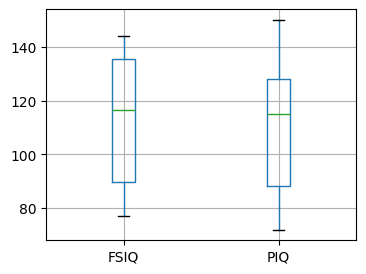

In [24]:
plt.figure(figsize=(4, 3))
data.boxplot(column=["FSIQ", "PIQ"])

In [25]:
sp.stats.ttest_ind(data["FSIQ"], data["PIQ"])

TtestResult(statistic=np.float64(0.465637596380964), pvalue=np.float64(0.6427725009414841), df=np.float64(78.0))

In [26]:
sp.stats.ttest_rel(data["FSIQ"], data["PIQ"])

TtestResult(statistic=np.float64(1.7842019405859857), pvalue=np.float64(0.08217263818364236), df=np.int64(39))

The paired t-test is more appropriate because FSIQ and PIQ were measured on the same individuals. The p-value is greater than 0.05, so the difference between mean FSIQ and mean PIQ is not statistically significant.

([<matplotlib.axis.XTick at 0x14cbae765600>], [Text(1, 0, 'FSIQ - PIQ')])

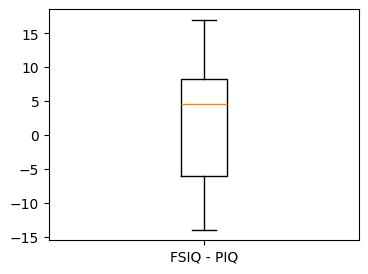

In [27]:
plt.figure(figsize=(4, 3))
plt.boxplot(data["FSIQ"] - data["PIQ"])
plt.xticks((1,), ("FSIQ - PIQ",))

In [28]:
sp.stats.ttest_1samp(data["FSIQ"] - data["PIQ"], 0)

TtestResult(statistic=np.float64(1.7842019405859857), pvalue=np.float64(0.08217263818364236), df=np.int64(39))

In [29]:
sp.stats.wilcoxon(
    data["FSIQ"],
    data["PIQ"],
    method="approx"
)

WilcoxonResult(statistic=np.float64(274.5), pvalue=np.float64(0.10659492713506856))

The paired Wilcoxon test also gives a p-value greater than 0.05. Both the parametric and nonparametric paired tests indicate that the difference between FSIQ and PIQ is not statistically significant.

In [30]:
female_weight = data[data["Gender"] == "Female"]["Weight"].dropna()
male_weight = data[data["Gender"] == "Male"]["Weight"].dropna()

print("Female sample size:", len(female_weight))
print("Male sample size:", len(male_weight))
print("Female mean weight:", female_weight.mean())
print("Male mean weight:", male_weight.mean())

Female sample size: 20
Male sample size: 18
Female mean weight: 137.2
Male mean weight: 166.44444444444446


In [31]:
sp.stats.ttest_ind(female_weight, male_weight)

TtestResult(statistic=np.float64(-4.870950921940696), pvalue=np.float64(2.227293018362118e-05), df=np.float64(36.0))

The p-value is much smaller than 0.05, so the null hypothesis is rejected. There is a statistically significant difference in mean weight between female and male participants. The negative test statistic indicates that the female group had a lower mean weight than the male group.

## Linear Models, Multiple Factors, and Analysis of Variance

### A Simple Linear Regression

This section creates simulated data and uses ordinary least squares regression to examine the linear relationship between x and y.

In [32]:
x = np.linspace(-5, 5, 20)

rng = np.random.default_rng(27446968)

y = -5 + 3 * x + 4 * rng.normal(size=x.shape)

data = pd.DataFrame({"x": x, "y": y})

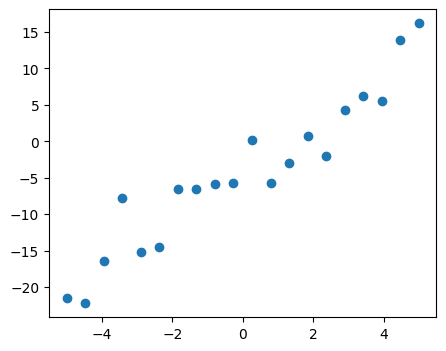

In [33]:
plt.figure(figsize=(5, 4))
plt.plot(x, y, "o");

In [34]:
import statsmodels.formula.api as smf

model = smf.ols("y ~ x", data).fit()

In [35]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     164.5
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           1.72e-10
Time:                        00:56:24   Log-Likelihood:                -51.758
No. Observations:                  20   AIC:                             107.5
Df Residuals:                      18   BIC:                             109.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.2948      0.759     -5.661      0.000      -5.889      -2.701
x              3.2060      0.250     12.825      0.000       2.681       3.731
==============================================================================
Omnibus:                        1.218   Durbin-Watson:                   1.796
Prob(Omnibus):                  0.544   Jarque-Bera (JB):                0.999
Skew:                           0.503   Prob(JB):                        0.607
Kurtosis:                       2.568   Cond. No.                         3.03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [36]:
model.params

Intercept   -4.294824
x            3.205979
dtype: float64

The estimated slope for x is approximately 3.21, meaning that y increases by about 3.21 units for every one-unit increase in x. The p-value for x is below 0.05, indicating a statistically significant linear relationship between x and y. The R-squared value of approximately 0.90 means that the model explains about 90% of the variation in y.

### Categorical Variables: Comparing Groups

This section uses a categorical variable in a linear regression model to compare VIQ scores between female and male participants.

In [37]:
data = pd.read_csv(
    "../examples/brain_size.csv",
    sep=";",
    na_values="."
)

In [38]:
model = smf.ols("VIQ ~ Gender + 1", data).fit()

In [39]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    VIQ   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.5969
Date:                Tue, 28 Jul 2026   Prob (F-statistic):              0.445
Time:                        00:56:24   Log-Likelihood:                -182.42
No. Observations:                  40   AIC:                             368.8
Df Residuals:                      38   BIC:                             372.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        109.4500      5.308     20.619      0.000      98.704     120.196
Gender[T.Male]     5.8000      7.507      0.773      0.445      -9.397      20.997
==============================================================================
Omnibus:                       26.188   Durbin-Watson:                   1.709
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                3.703
Skew:                           0.010   Prob(JB):                        0.157
Kurtosis:                       1.510   Cond. No.                         2.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The intercept represents the mean VIQ score for female participants, which is 109.45. The coefficient for `Gender[T.Male]` is 5.80, indicating that the male group had an average VIQ score that was 5.80 points higher than the female group. However, the p-value is greater than 0.05, so this difference is not statistically significant.

### Link to the T-Test Between FSIQ and PIQ

The FSIQ and PIQ measurements are placed into a long-form table so that the type of IQ measurement can be used as a categorical variable.

In [40]:
data_fisq = pd.DataFrame({
    "iq": data["FSIQ"],
    "type": "fsiq"
})

data_piq = pd.DataFrame({
    "iq": data["PIQ"],
    "type": "piq"
})

data_long = pd.concat((data_fisq, data_piq))

data_long

,iq,type
0,133,fsiq
1,140,fsiq
2,139,fsiq
3,133,fsiq
4,137,fsiq
...,...,...
35,128,piq
36,124,piq
37,94,piq
38,74,piq


In [41]:
model = smf.ols("iq ~ type", data_long).fit()

In [42]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     iq   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.2168
Date:                Tue, 28 Jul 2026   Prob (F-statistic):              0.643
Time:                        00:56:24   Log-Likelihood:                -364.35
No. Observations:                  80   AIC:                             732.7
Df Residuals:                      78   BIC:                             737.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     113.4500      3.683     30.807      0.000     106.119     120.781
type[T.piq]    -2.4250      5.208     -0.466      0.643     -12.793       7.943
==============================================================================
Omnibus:                      164.598   Durbin-Watson:                   1.531
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                8.062
Skew:                          -0.110   Prob(JB):                       0.0178
Kurtosis:                       1.461   Cond. No.                         2.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [43]:
sp.stats.ttest_ind(data["FSIQ"], data["PIQ"])

TtestResult(statistic=np.float64(0.465637596380964), pvalue=np.float64(0.6427725009414841), df=np.float64(78.0))

The coefficient for `type[T.piq]` is -2.425, meaning that the mean PIQ score is approximately 2.43 points lower than the mean FSIQ score. However, the p-value is greater than 0.05, so the difference is not statistically significant. The regression model and the independent-sample t-test produce the same statistical conclusion.

### Multiple Regression: Including Multiple Factors

This section examines how multiple independent variables can be included in the same regression model.

Text(0.5, 0, 'Z')

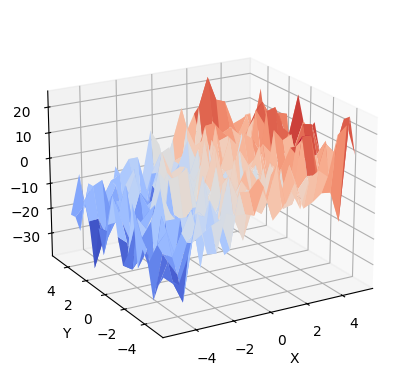

In [44]:
x = np.linspace(-5, 5, 21)

X, Y = np.meshgrid(x, x)

rng = np.random.default_rng(27446968)

Z = -5 + 3 * X - 0.5 * Y + 8 * rng.normal(size=X.shape)

ax = plt.figure().add_subplot(projection="3d")
surf = ax.plot_surface(
    X,
    Y,
    Z,
    cmap="coolwarm",
    rstride=1,
    cstride=1
)

ax.view_init(20, -120)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

The three-dimensional plot shows how z depends on both x and y. In a multiple regression model, the effect of each independent variable can be estimated while controlling for the other variable.

In [45]:
from pathlib import Path
from urllib.request import urlretrieve

Path("../examples").mkdir(exist_ok=True)

iris_file = Path("../examples/iris.csv")

if not iris_file.exists():
    urlretrieve(
        "https://lectures.scientific-python.org/_downloads/6c4b367d8ba9371e9254c70abb7496c5/iris.csv",
        iris_file
    )

print("Iris file exists:", iris_file.exists())

Iris file exists: True


### Multiple Regression with the Iris Dataset

The iris dataset contains sepal and petal measurements for three different iris species.

In [46]:
data = pd.read_csv("../examples/iris.csv")

data

,sepal_length,sepal_width,petal_length,petal_width,name
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


Text(0.5, 0.98, 'blue: setosa, green: versicolor, red: virginica')

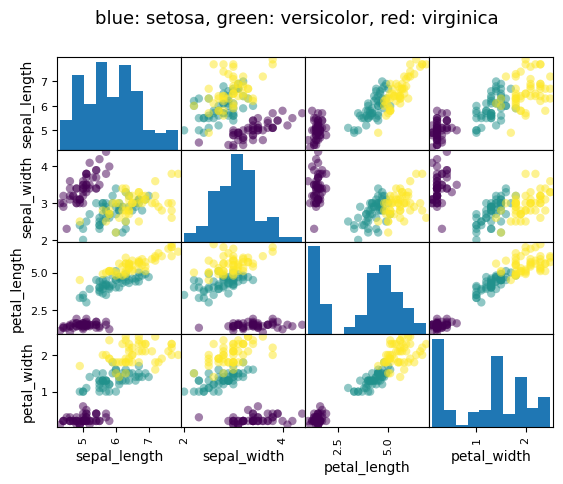

In [47]:
categories = pd.Categorical(data["name"])

pd.plotting.scatter_matrix(
    data,
    c=categories.codes,
    marker="o"
)

fig = plt.gcf()
fig.suptitle(
    "blue: setosa, green: versicolor, red: virginica",
    size=13
)

The scatter matrix shows relationships among the sepal and petal measurements. The colored points also show that the three iris species have different measurement patterns, although some groups overlap.

In [48]:
model = smf.ols(
    "sepal_width ~ name + petal_length",
    data
).fit()

In [49]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            sepal_width   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     44.63
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           1.58e-20
Time:                        00:56:25   Log-Likelihood:                -38.185
No. Observations:                 150   AIC:                             84.37
Df Residuals:                     146   BIC:                             96.41
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              2.9813      0.099     29.989      0.000       2.785       3.178
name[T.versicolor]    -1.4821      0.181     -8.190      0.000      -1.840      -1.124
name[T.virginica]     -1.6635      0.256     -6.502      0.000      -2.169      -1.158
petal_length           0.2983      0.061      4.920      0.000       0.178       0.418
==============================================================================
Omnibus:                        2.868   Durbin-Watson:                   1.753
Prob(Omnibus):                  0.238   Jarque-Bera (JB):                2.885
Skew:                          -0.082   Prob(JB):                        0.236
Kurtosis:                       3.659   Cond. No.                         54.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The model has an R-squared value of approximately 0.48, meaning that species and petal length explain about 48% of the variation in sepal width. The positive coefficient for petal length indicates that sepal width tends to increase as petal length increases when species is held constant. The species coefficients are also statistically significant.

### Post-Hoc Hypothesis Testing

This F-test compares the species coefficients for versicolor and virginica.

In [50]:
print(model.f_test([0, 1, -1, 0]))

<F test: F=3.245335346574177, p=0.0736905878170114, df_denom=146, df_num=1>


The p-value is greater than 0.05, so the difference between the versicolor and virginica coefficients is not statistically significant after controlling for petal length.

### Exercise: Gender and VIQ After Controlling for Other Variables

This analysis tests whether VIQ differs between female and male participants after controlling for MRI count, height, and weight.

In [51]:
data = pd.read_csv(
    "../examples/brain_size.csv",
    sep=";",
    na_values=".",
    index_col=0
)

In [52]:
model = smf.ols(
    "VIQ ~ Gender + MRI_Count + Height + Weight",
    data=data
).fit()

In [53]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    VIQ   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.158
Method:                 Least Squares   F-statistic:                     2.733
Date:                Tue, 28 Jul 2026   Prob (F-statistic):             0.0455
Time:                        00:56:26   Log-Likelihood:                -167.03
No. Observations:                  38   AIC:                             344.1
Df Residuals:                      33   BIC:                             352.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        169.7719     90.054      1.885      0.068     -13.443     352.987
Gender[T.Male]    10.1579     10.891      0.933      0.358     -12.001      32.317
MRI_Count          0.0002   6.48e-05      2.489      0.018    2.94e-05       0.000
Height            -2.7337      1.410     -1.938      0.061      -5.603       0.136
Weight            -0.1427      0.215     -0.665      0.511      -0.579       0.294
==============================================================================
Omnibus:                        5.002   Durbin-Watson:                   2.272
Prob(Omnibus):                  0.082   Jarque-Bera (JB):                1.892
Skew:                          -0.066   Prob(JB):                        0.388
Kurtosis:                       1.915   Cond. No.                     2.41e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.41e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

After controlling for MRI count, height, and weight, the coefficient for `Gender[T.Male]` is 10.16. This means that male participants had an estimated VIQ score about 10.16 points higher than female participants when the other variables were held constant. However, the p-value is 0.358, which is greater than 0.05, so the gender difference is not statistically significant. MRI count was the only significant predictor in this model, with a p-value of 0.018.

## More Visualization: Seaborn for Statistical Exploration

This section uses the wage dataset and Seaborn plots to examine relationships among wage, age, education, and sex.

In [54]:
from pathlib import Path

print("Current directory:", Path.cwd())
print("Wage file exists:", Path("../examples/wages.txt").exists())

Current directory: /users/PAS2437/zhao0226/bash_tutorial/Assignment4-Stats-Scripts/notebooks
Wage file exists: True


In [55]:
data = pd.read_csv(
    "../examples/wages.txt",
    skiprows=27,
    skipfooter=6,
    sep=None,
    header=None,
    engine="python"  # To allow use of skipfooter.
)

names = [
    "education: Number of years of education",
    "south: 1=person lives in South, 0=Person lives elsewhere",
    "sex: 1=female, 0=Male",
    "experience: Number of years of work experience",
    "union: 1=union member, 0=Not union member",
    "wage: wage (dollars per hour)",
    "age: years",
    "race: 1=other, 2=Hispanic, 3=White",
    "occupation: 1=Management, 2=Sales, 3=Clerical, 4=Service, 5=Professional, 6=Other",
    "sector: 0=Other, 1=Manufacturing, 2=Construction",
    "marr: 0=unmarried, 1=Married",
]

short_names = [n.split(":")[0] for n in names]
data.columns = pd.Index(short_names)

data["wage"] = np.log10(data["wage"])
data["sex"] = np.choose(data["sex"], ["male", "female"])

data

,education,south,sex,experience,union,wage,age,race,occupation,sector,marr
0,8,0,female,21,0,0.707570,35,2,6,1,1
1,9,0,female,42,0,0.694605,57,3,6,1,1
2,12,0,male,1,0,0.824126,19,3,6,1,0
3,12,0,male,4,0,0.602060,22,3,6,0,0
4,12,0,male,17,0,0.875061,35,3,6,0,1
...,...,...,...,...,...,...,...,...,...,...,...
529,18,0,male,5,0,1.055378,29,3,5,0,0
530,12,0,female,33,0,0.785330,51,1,5,0,1
531,17,0,female,25,1,1.366423,48,1,5,0,1
532,12,1,male,13,1,1.298416,31,3,5,0,1


In [56]:
data.shape

(534, 11)

### Pairplot of Continuous Variables

This plot examines the relationships among wage, age, and education.

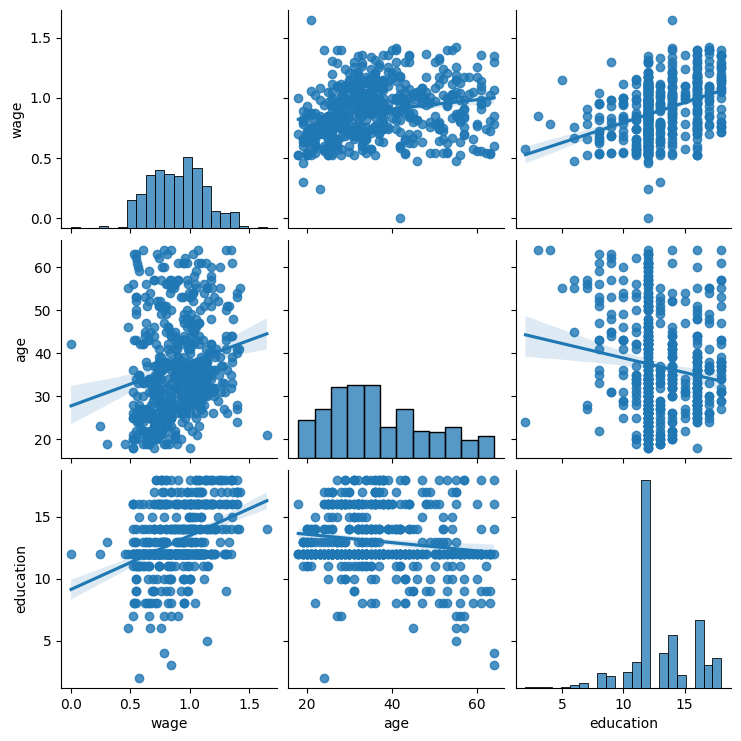

In [57]:
seaborn.pairplot(
    data,
    vars=["wage", "age", "education"],
    kind="reg"
);

The pairplot shows the distributions and pairwise relationships among wage, age, and education. The regression lines show the general direction of each relationship.

### Pairplot Grouped by Sex

This plot compares the relationships among wage, age, and education for male and female participants.

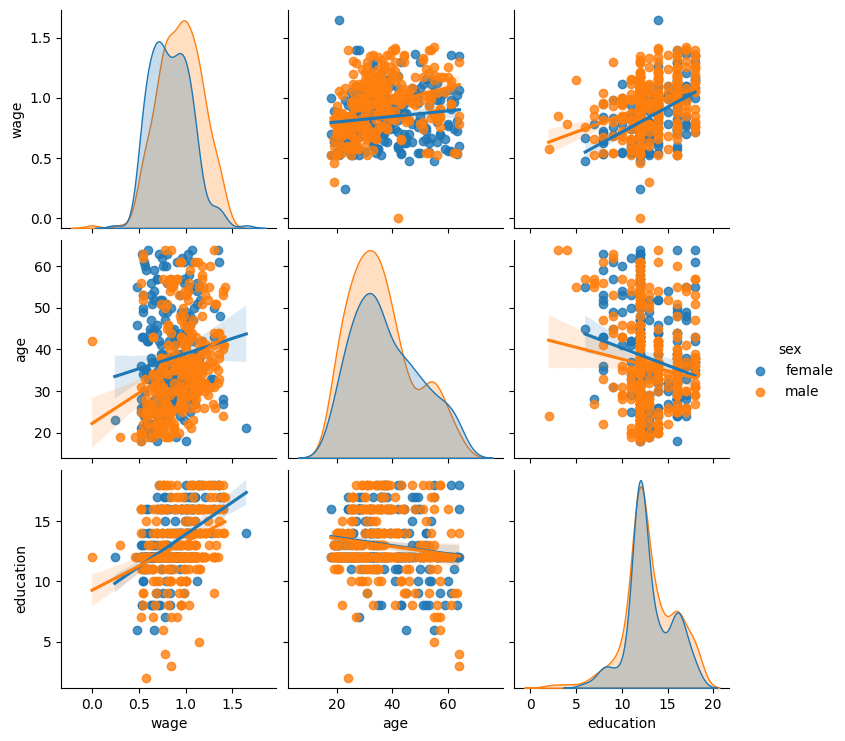

In [58]:
seaborn.pairplot(
    data,
    vars=["wage", "age", "education"],
    kind="reg",
    hue="sex"
);

The two groups overlap, but the fitted regression lines allow the relationships among the variables to be compared between male and female participants.

### Wage and Education Regression Plot

This plot examines the relationship between education and log-transformed wage.

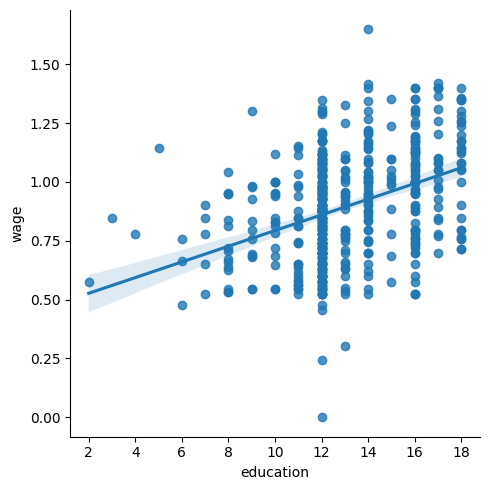

In [59]:
seaborn.lmplot(
    y="wage",
    x="education",
    data=data
);

The fitted regression line shows a positive relationship between education and log-transformed wage. Participants with more years of education generally tend to have higher wages.

## Testing for Interactions

This section tests whether the relationship between education and wage differs between male and female participants.

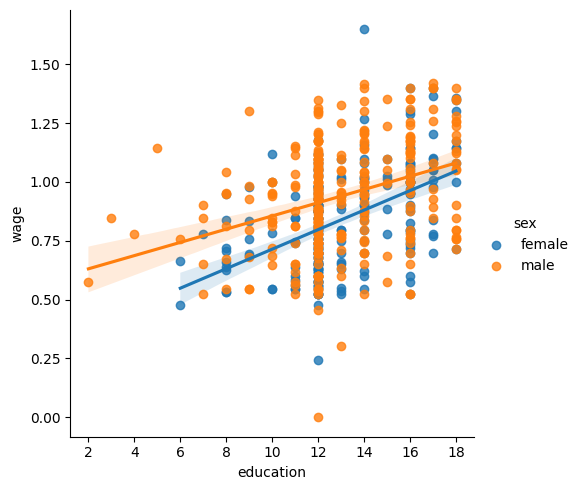

In [60]:
seaborn.lmplot(
    y="wage",
    x="education",
    hue="sex",
    data=data
);

The plot shows separate regression lines for male and female participants. The lines appear to have different intercepts and slightly different slopes, but a statistical model is needed to determine whether these differences are significant.

### Model Without an Interaction

The first model tests whether education and sex separately contribute to wage.

In [61]:
result = smf.ols(
    formula="wage ~ education + sex",
    data=data
).fit()

In [62]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     63.42
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           2.01e-25
Time:                        00:56:31   Log-Likelihood:                 86.654
No. Observations:                 534   AIC:                            -167.3
Df Residuals:                     531   BIC:                            -154.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.4053      0.046      8.732      0.000       0.314       0.496
sex[T.male]     0.1008      0.018      5.625      0.000       0.066       0.136
education       0.0334      0.003      9.768      0.000       0.027       0.040
==============================================================================
Omnibus:                        4.675   Durbin-Watson:                   1.792
Prob(Omnibus):                  0.097   Jarque-Bera (JB):                4.876
Skew:                          -0.147   Prob(JB):                       0.0873
Kurtosis:                       3.365   Cond. No.                         69.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Both education and sex have p-values below 0.05, so they are statistically significant predictors of log-transformed wage. The positive education coefficient indicates that wage tends to increase as years of education increase. The positive coefficient for `sex[T.male]` indicates that male participants had a higher predicted wage than female participants when education was held constant.

### Model With an Interaction

The interaction term tests whether the effect of education on wage differs between male and female participants.

In [63]:
result = smf.ols(
    formula="wage ~ education + sex + education * sex",
    data=data
).fit()

In [64]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     43.72
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           2.94e-25
Time:                        00:56:31   Log-Likelihood:                 88.503
No. Observations:                 534   AIC:                            -169.0
Df Residuals:                     530   BIC:                            -151.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.2998      0.072      4.173      0.000       0.159       0.441
sex[T.male]               0.2750      0.093      2.972      0.003       0.093       0.457
education                 0.0415      0.005      7.647      0.000       0.031       0.052
education:sex[T.male]    -0.0134      0.007     -1.919      0.056      -0.027       0.000
==============================================================================
Omnibus:                        4.838   Durbin-Watson:                   1.825
Prob(Omnibus):                  0.089   Jarque-Bera (JB):                5.000
Skew:                          -0.156   Prob(JB):                       0.0821
Kurtosis:                       3.356   Cond. No.                         194.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The interaction coefficient for `education:sex[T.male]` is approximately -0.0134, with a p-value of about 0.056. Because the p-value is slightly greater than 0.05, the interaction is not statistically significant. Therefore, the data do not provide enough evidence to conclude that the relationship between education and wage differs between male and female participants.

## Conclusion

This walkthrough used descriptive statistics, hypothesis tests, regression models, and visualizations to examine relationships in several datasets. The results show how p-values can be used to evaluate group differences and predictor effects. Multiple regression and interaction terms also demonstrate how additional variables can change the interpretation of a statistical model.